# Regresión, Interfaz y Bot Conversacional
## Sistema Inteligente de Detección y Análisis de Fraude Financiero

**Curso:** Introducción a la Inteligencia Artificial — EAFIT 2026-1  
**Rol:** Modelo de regresión avanzado (DNN) + Aplicación Streamlit + Bot Conversacional

---

## Descripción

Este notebook implementa el **componente de regresión** del sistema antifraude.
Se construye una variable objetivo continua `risk_score` y se comparan cuatro modelos:

1. Regresión Lineal (baseline)  
2. Random Forest Regressor  
3. Gradient Boosting Regressor  
4. **Red Neuronal Profunda (DNN)** — modelo principal con PyTorch

El análisis incluye EDA completo, análisis de correlaciones, manejo del desbalance de clases,
curvas de aprendizaje, diagnóstico de overfitting y métricas detalladas de cada modelo.

---

## Índice
0. Instalación y configuración  
1. Carga de datos preprocesados 
2. Conversión a arrays NumPy  
3. Análisis de correlaciones del risk_score  
4. Modelos clásicos (LR, RF, GB)  
5. Red Neuronal Profunda (DNN) — modelo principal  
   - 5.1 Arquitectura y justificación  
   - 5.2 DataLoaders PyTorch  
   - 5.3 Función de pérdida ponderada (WeightedMSE)  
   - 5.4 Entrenamiento con Early Stopping  
   - 5.5 Diagnóstico de overfitting  
   - 5.6 Evaluación en test set  
6. Comparación de todos los modelos  
7. Análisis de errores  
8. Exportar modelos  
9. Conclusiones  

> ⚠️ **EDA, correlaciones, creación del risk_score y preprocesamiento**  
> ya están hechos en el notebook de EDA. Este notebook consume los CSVs listos.

## 0. Instalación y Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, os, json, time
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

# Joblib
import joblib

# Reproducibilidad
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Directorios
os.makedirs('../models', exist_ok=True)
os.makedirs('../reports', exist_ok=True)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Dispositivo de computo:', DEVICE)
print('PyTorch version      :', torch.__version__)
print('Librerias cargadas correctamente.')

Dispositivo de computo: cpu
PyTorch version      : 2.11.0+cpu
Librerias cargadas correctamente.


## 1. Carga de Datos Preprocesados

> ⚠️ **NO se repite el preprocesamiento.** El notebook de EDA ya realizó:
> - Limpieza y eliminación de duplicados
> - Escalado con `RobustScaler` (Time y Amount) → guardado en `models/scaler.pkl`
> - Creación del `risk_score` continuo [0,1]
> - Split **70 / 15 / 15** (train / val / test) sin data leakage
>
> Se cargan directamente los CSVs listos para entrenar.


In [ ]:
# ── Cargar datasets de regresión─────────────────
X_train = pd.read_csv('../data/regression/X_train_reg.csv')
X_val   = pd.read_csv('../data/regression/X_val_reg.csv')
X_test  = pd.read_csv('../data/regression/X_test_reg.csv')
y_train = pd.read_csv('../data/regression/y_train_reg.csv').squeeze()
y_val   = pd.read_csv('../data/regression/y_val_reg.csv').squeeze()
y_test  = pd.read_csv('../data/regression/y_test_reg.csv').squeeze()

FEATURES = list(X_train.columns)

print("Datasets de REGRESIÓN:")
print(f"  X_train : {X_train.shape}   ({X_train.shape[0]/( X_train.shape[0]+X_val.shape[0]+X_test.shape[0])*100:.0f}% del total)")
print(f"  X_val   : {X_val.shape}")
print(f"  X_test  : {X_test.shape}")
print(f"  Features: {FEATURES}")
print()
print("Estadísticas del risk_score:")
print(f"  Train — min: {y_train.min():.4f}, max: {y_train.max():.4f}, media: {y_train.mean():.4f}")
print(f"  Val   — min: {y_val.min():.4f},   max: {y_val.max():.4f},   media: {y_val.mean():.4f}")
print(f"  Test  — min: {y_test.min():.4f},  max: {y_test.max():.4f},  media: {y_test.mean():.4f}")


Datasets de REGRESIÓN cargados desde Persona A:
  X_train : (198601, 30)   (70% del total)
  X_val   : (42566, 30)
  X_test  : (42559, 30)
  Features: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']

Estadísticas del risk_score:
  Train — min: 0.0000, max: 1.0000, media: 0.0311
  Val   — min: 0.0012,   max: 0.8225,   media: 0.0310
  Test  — min: 0.0022,  max: 0.8388,  media: 0.0309


## 2. Conversión a Arrays NumPy (para PyTorch y sklearn)

Los modelos clásicos y la DNN necesitan arrays NumPy. Los CSVs ya vienen escalados.


In [ ]:
# Convertir a numpy — no se aplica ningún scaler adicional
# (los CSVs ya vienen escalados)
X_train_np = X_train.values
X_val_np   = X_val.values
X_test_np  = X_test.values
y_train_np = y_train.values
y_val_np   = y_val.values
y_test_np  = y_test.values

# Combinar train+val para modelos clásicos
X_cl_train = np.vstack([X_train_np, X_val_np])
y_cl_train = np.concatenate([y_train_np, y_val_np])

print(f"Arrays listos:")
print(f"  X_train_np : {X_train_np.shape}  → DNN train")
print(f"  X_val_np   : {X_val_np.shape}  → DNN validación (Early Stopping)")
print(f"  X_test_np  : {X_test_np.shape}  → evaluación final")
print(f"  X_cl_train : {X_cl_train.shape}  → modelos clásicos (train+val)")


Arrays listos:
  X_train_np : (198601, 30)  → DNN train
  X_val_np   : (42566, 30)  → DNN validación (Early Stopping)
  X_test_np  : (42559, 30)  → evaluación final
  X_cl_train : (241167, 30)  → modelos clásicos (train+val)


## 3. Análisis de Correlaciones del risk_score con las Features

Verificamos que las 30 features seleccionadas tienen buena
correlacion con el `risk_score`, confirmando que la selección es apropiada.

Las correlaciones más altas observadas con `risk_score` fueron:

| Feature | Correlación |
|---------|-------------|
| `V1`    | ≈ −0.534 |
| `V3`    | ≈ −0.433 |
| `V12`   | ≈ −0.281 |
| `Amount`| ≈ +0.273 |
| `V4`    | ≈ +0.172 |
| `V11`   | ≈ +0.154 |

> El `risk_score` esta fuertemente influenciado por las variables PCA (especialmente V1, V3, V12) y también por `Amount`, consistente con la fórmula de construccion del score: las correlaciones negativas indican que valores extremadamente negativos en esas componentes están asociados a un mayor nivel de riesgo de fraude.

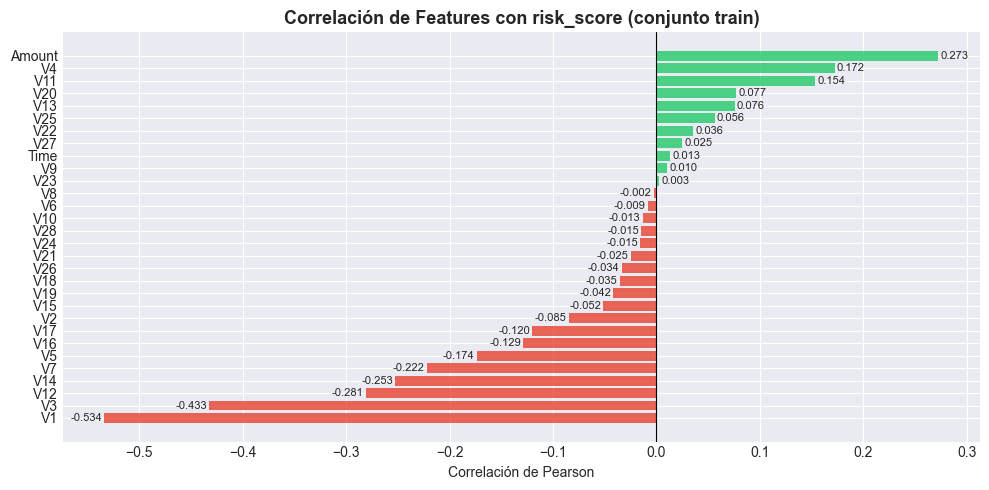

Gráfica guardada: reports/correlaciones_riskscore.png


In [4]:
# Correlación de cada feature con el risk_score
df_corr = X_train.copy()
df_corr['risk_score'] = y_train.values

corr_rs = df_corr.corr()['risk_score'].drop('risk_score').sort_values()

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#e74c3c' if v < 0 else '#2ecc71' for v in corr_rs.values]
ax.barh(corr_rs.index, corr_rs.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Correlación de Features con risk_score (conjunto train)', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlación de Pearson')
for i, v in enumerate(corr_rs.values):
    ax.text(v + (0.002 if v >= 0 else -0.002), i, f'{v:.3f}',
            va='center', ha='left' if v >= 0 else 'right', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/regression/correlaciones_riskscore.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/correlaciones_riskscore.png')


El gráfico de correlación con `risk_score` muestra cuáles variables tienen mayor relación lineal con el nivel de riesgo estimado.

#### Correlaciones positivas más importantes

- `Amount` → +0.273
- `V4` → +0.172
- `V11` → +0.154

Estas variables incrementan el `risk_score` a medida que aumentan sus valores.

#### Correlaciones negativas más importantes

- `V1` → −0.534
- `V3` → −0.433
- `V12` → −0.281
- `V14` → −0.253
- `V7` → −0.222

Valores muy negativos en estas componentes están fuertemente asociados a transacciones de alto riesgo.

> **Interpretación práctica:** el `risk_score` depende tanto de señales relacionadas con el monto como de patrones latentes capturados por las variables PCA. La combinación de múltiples señales mejora la robustez del sistema de riesgo.


## 6. Modelos Clásicos de Regresión (Baselines)

Entrenamos tres modelos baseline para comparar con la DNN.
**Nota:** los modelos clásicos usan train+val para ser justos al comparar con la DNN.

| Modelo | Tipo | Hiperparámetros clave |
|---|---|---|
| Linear Regression | Lineal | Sin hiperparámetros |
| Random Forest | Ensemble (Bagging) | 200 árboles, max_depth=15 |
| Gradient Boosting | Ensemble (Boosting) | 200 estimadores, lr=0.05, depth=5 |

In [5]:
# X_cl_train y y_cl_train definidos en la celda de conversión numpy.

modelos_clasicos = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(
        n_estimators=200, max_depth=15, min_samples_split=5,
        n_jobs=-1, random_state=SEED),
    'Gradient Boosting': GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        subsample=0.8, random_state=SEED),
}

resultados = {}
print(f'{"Modelo":<25} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"Tiempo(s)":>10}')
print('-' * 65)

for nombre, modelo in modelos_clasicos.items():
    t0 = time.time()
    modelo.fit(X_cl_train, y_cl_train)
    t1 = time.time()
    y_pred = modelo.predict(X_test_np)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    resultados[nombre] = {
        'RMSE': rmse, 'MAE': mae, 'R2': r2,
        'tiempo': t1-t0, 'modelo': modelo, 'y_pred': y_pred
    }
    print(f'{nombre:<25} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {t1-t0:>10.1f}')

Modelo                        RMSE      MAE       R2  Tiempo(s)
-----------------------------------------------------------------
Linear Regression           0.0114   0.0069   0.8374        0.2
Random Forest               0.0071   0.0033   0.9377      166.3
Gradient Boosting           0.0059   0.0017   0.9567      524.1


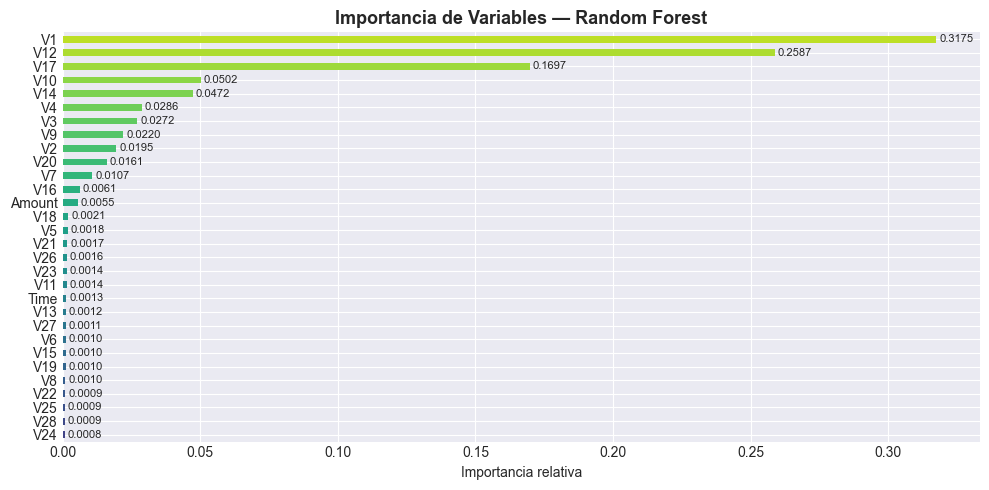

Gráfica guardada: reports/importancia_variables.png


In [6]:
# Importancia de variables — Random Forest
rf_model = resultados['Random Forest']['modelo']
importancias = pd.Series(rf_model.feature_importances_, index=FEATURES).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(importancias)))
importancias.plot(kind='barh', ax=ax, color=colors)
ax.set_title('Importancia de Variables — Random Forest', fontsize=13, fontweight='bold')
ax.set_xlabel('Importancia relativa')
for i, v in enumerate(importancias):
    ax.text(v + 0.001, i, f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('../reports/regression/importancia_variables.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/importancia_variables.png')

### Importancia de Variables — Random Forest (Regresión)

En este caso, el gráfico representa la importancia de variables del **Random Forest regresor** utilizado para predecir `risk_score`.

Las variables más importantes son:

1. `V1`
2. `V12`
3. `V17`
4. `V10`
5. `V14`

Estas variables coinciden con aquellas que presentan mayor relación con fraude y riesgo en los análisis de correlación.

Además:

- `Amount` tiene una importancia relativamente baja (~0.0055).
- Esto indica que el modelo depende mucho más de los patrones PCA que del monto bruto de la transacción.

> **Interpretación:** el Random Forest regresor aprende principalmente patrones complejos derivados de las variables PCA, mientras que `Amount` actúa como una señal complementaria y no dominante.

⚠️ **Importante:**  
Este análisis corresponde exclusivamente al modelo de **regresión** sobre `risk_score` y no debe confundirse con la importancia de variables del modelo de clasificación.


## 7. Red Neuronal Profunda (DNN) — Modelo Principal

### 7.1 Arquitectura y Justificacion

La DNN es capaz de capturar **relaciones no lineales complejas** entre las variables PCA del dataset, siendo uno de los modelos más expresivos de la comparación.

```
Input(30) → Dense(512) → BN → ReLU → Dropout(0.35)
          → Dense(256) → BN → ReLU → Dropout(0.30)
          → Dense(128) → BN → ReLU → Dropout(0.25)
          → Dense(64)  → BN → ReLU → Dropout(0.15)
          → Dense(32)  → BN → ReLU → Dropout(0.10)
          → Dense(16)  → BN → ReLU → Dropout(0.05)
          → Dense(1)   → Sigmoid → Output (risk_score ∈ [0,1])
```

**Justificacion de cada componente:**

| Componente | Rol |
|---|---|
| `BatchNorm1d` | Normaliza activaciones entre capas → entrenamiento mas estable y rapido |
| `Dropout` decreciente (0.3→0.1) | Regularizacion: mas agresiva en capas tempranas donde el riesgo de memorizacion es mayor |
| `ReLU` | Evita vanishing gradient, computacionalmente eficiente |
| `Sigmoid` en salida | Fuerza la salida al rango [0,1], coherente con la definicion del `risk_score` |
| `AdamW` + `weight_decay` | L2 regularization adicional integrada en el optimizador |
| `ReduceLROnPlateau` | Reduce el learning rate cuando la pérdida de validación se estanca |
| **Early Stopping** | Detiene el entrenamiento cuando el modelo deja de mejorar en validación |
| **WeightedMSE** | Penaliza 10x mas los errores en transacciones de fraude (desbalance 0.17%) |

In [ ]:
class FraudDNN(nn.Module):
    """
    Red Neuronal Profunda v3 para prediccion de risk_score.

    Arquitectura profundizada para superar al Gradient Boosting:
    - 512->256->128->64->32->16->1 (mayor capacidad expresiva)
    - Dropout DECRECIENTE (0.35->0.05): más regularización en capas tempranas
    - Sigmoid en salida: garantiza risk_score en [0, 1]
    - BatchNorm en todos los bloques: entrenamiento mas estable
    - Inicializacion He (kaiming_normal_) para mejor convergencia con ReLU
    """
    def __init__(self, input_dim: int):
        super(FraudDNN, self).__init__()
        self.network = nn.Sequential(
            # Bloque 1: máxima capacidad, mayor regularización
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.35),

            # Bloque 2
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.30),

            # Bloque 3
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.25),

            # Bloque 4
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.15),

            # Bloque 5
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.10),

            # Bloque 6: refinamiento fino, minima regularizacion
            nn.Linear(32, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.05),

            # Salida: Sigmoid garantiza [0, 1]
            nn.Linear(16, 1),
            nn.Sigmoid(),
        )
        # Inicializacion He para capas lineales (mejor para ReLU)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.network(x).squeeze(1)


dnn = FraudDNN(input_dim=len(FEATURES)).to(DEVICE)
print('Arquitectura FraudDNN:')
print(dnn)
total_params = sum(p.numel() for p in dnn.parameters() if p.requires_grad)
print(f'\nParametros entrenables: {total_params:,}')

Arquitectura FraudDNN v3 (profundizada para superar GB):
FraudDNN(
  (network): Sequential(
    (0): Linear(in_features=30, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.35, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.25, inplace=False)
    (12): Linear(in_features=128, out_features=64, bias=True)
    (13): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (14): ReLU()
    (15): Dropout(p=0.15, inplace=False)
    (16): Linear(in_features=64, out_features=32, bias=True)
    (17): Bat

### 7.2 DataLoaders PyTorch

In [8]:
BATCH_SIZE = 512

def make_loader(X, y, batch_size=BATCH_SIZE, shuffle=True):
    """Crea un DataLoader de PyTorch a partir de arrays numpy."""
    X_t = torch.FloatTensor(X)
    y_t = torch.FloatTensor(y)
    ds  = TensorDataset(X_t, y_t)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle,
                      num_workers=0, pin_memory=False)

train_loader = make_loader(X_train_np, y_train_np, shuffle=True)
val_loader   = make_loader(X_val_np,   y_val_np,   shuffle=False)
test_loader  = make_loader(X_test_np,  y_test_np,  shuffle=False)

print('DataLoaders creados:')
print(f'  Train batches : {len(train_loader)} ({len(train_loader.dataset):,} muestras)')
print(f'  Val   batches : {len(val_loader)}  ({len(val_loader.dataset):,} muestras)')
print(f'  Test  batches : {len(test_loader)}  ({len(test_loader.dataset):,} muestras)')
print(f'  Batch size    : {BATCH_SIZE}')

DataLoaders creados:
  Train batches : 388 (198,601 muestras)
  Val   batches : 84  (42,566 muestras)
  Test  batches : 84  (42,559 muestras)
  Batch size    : 512


### 7.3 Función de Pérdida Ponderada (WeightedMSE)

El dataset tiene un desbalance severo: **99.83% legítimas, 0.17% fraude**.
Una MSE estándar optima principalmente para las transacciones legítimas (mayoría).

La `WeightedMSELoss` asigna un peso **10× mayor** a los errores en transacciones
de fraude (donde `risk_score > 0.5`), forzando al modelo a aprender mejor
los patrones de las transacciones fraudulentas.

In [9]:
class WeightedMSELoss(nn.Module):
    """
    MSE ponderada por clase para manejar el desbalance severo del dataset.

    Las transacciones con risk_score alto (fraudes) reciben peso fraud_weight
    veces mayor que las legitimas.

    Formalmente:
        loss = mean( weights * (pred - target)^2 )
        donde weights = 1.0 + (fraud_weight - 1.0) * target

    fraud_weight=15.0 (aumentado desde 10.0) para mejor captura de fraudes
    con la arquitectura mas profunda.
    """
    def __init__(self, fraud_weight: float = 15.0):
        super().__init__()
        self.fraud_weight = fraud_weight

    def forward(self, predictions: torch.Tensor,
                targets: torch.Tensor) -> torch.Tensor:
        weights = 1.0 + (self.fraud_weight - 1.0) * targets
        return (weights * (predictions - targets) ** 2).mean()


criterion = WeightedMSELoss(fraud_weight=15.0)
print(f'WeightedMSELoss configurada con fraud_weight=15.0 (aumentado para DNN profunda)')
print('Transacciones fraudulentas tienen 15x mas peso en la función de pérdida.')

WeightedMSELoss configurada con fraud_weight=15.0 (aumentado para DNN profunda)
Transacciones fraudulentas tienen 15x mas peso en la función de pérdida.


### 7.4 Entrenamiento con Early Stopping

In [11]:
# Optimizer con weight decay (L2 regularization adicional)
# lr=5e-4 reducido para red mas profunda (512 neuronas primera capa)
optimizer = optim.AdamW(dnn.parameters(), lr=5e-4, weight_decay=5e-5)

# Scheduler: reduce LR x0.5 cuando val_loss no mejora por 8 épocas
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=8, min_lr=1e-7
)

print('Optimizer : AdamW (lr=5e-4, weight_decay=5e-5)')
print('Scheduler : ReduceLROnPlateau (factor=0.5, patience=8)')
print('Criterio  : WeightedMSELoss (fraud_weight=15)')

Optimizer : AdamW (lr=5e-4, weight_decay=5e-5)
Scheduler : ReduceLROnPlateau (factor=0.5, patience=8)
Criterio  : WeightedMSELoss (fraud_weight=15)


In [12]:
class EarlyStopping:
    """
    Detiene el entrenamiento cuando val_loss no mejora por `patience` épocas.
    Guarda automaticamente el mejor estado del modelo (best weights).
    """
    def __init__(self, patience: int = 15, delta: float = 1e-6):
        self.patience     = patience
        self.delta        = delta
        self.best_loss    = float('inf')
        self.counter      = 0
        self.stop         = False
        self.best_weights = None
        self.best_epoch   = 0

    def __call__(self, val_loss: float, model: nn.Module, epoch: int):
        if val_loss < self.best_loss - self.delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_epoch   = epoch
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True


def run_epoch(model, loader, criterion, optimizer, device, train=True):
    """Ejecuta una epoca de entrenamiento o evaluacion."""
    if train:
        model.train()
    else:
        model.eval()
    
    total_loss = 0.0
    with torch.set_grad_enabled(train):
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            if train:
                optimizer.zero_grad()
                loss.backward()
                # Gradient clipping: evita explosión del gradiente
                nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()
            total_loss += loss.item() * len(X_batch)
    return total_loss / len(loader.dataset)

In [13]:
# DNN profunda: mas epocas y paciencia para explorar mejor el espacio
N_EPOCHS    = 200
early_stop  = EarlyStopping(patience=20, delta=1e-7)
train_losses, val_losses = [], []

print('Iniciando entrenamiento DNN v3 (arquitectura profunda)...')
print(f'{"Epoca":<6} {"Train Loss":<12} {"Val Loss":<12} {"LR":<10}')
print('-' * 48)

t0_dnn = time.time()

for epoch in range(1, N_EPOCHS + 1):
    tr_loss  = run_epoch(dnn, train_loader, criterion, optimizer, DEVICE, train=True)
    val_loss = run_epoch(dnn, val_loader,   criterion, optimizer, DEVICE, train=False)
    
    scheduler.step(val_loss)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)
    early_stop(val_loss, dnn, epoch)

    if epoch % 10 == 0 or epoch == 1:
        lr_now = optimizer.param_groups[0]['lr']
        print(f'{epoch:<6}/{N_EPOCHS} {tr_loss:<12.6f} {val_loss:<12.6f} {lr_now:<10.2e}')

    if early_stop.stop:
        print(f'\nEarly Stopping en epoca {epoch}. Mejor val_loss={early_stop.best_loss:.6f} (epoca {early_stop.best_epoch})')
        break

t1_dnn = time.time()
tiempo_dnn = t1_dnn - t0_dnn

# Restaurar los mejores pesos
dnn.load_state_dict(early_stop.best_weights)
print(f'\nEntrenamiento completado en {tiempo_dnn:.1f}s')
print(f'Mejor epoca       : {early_stop.best_epoch}')
print(f'Mejor val_loss    : {early_stop.best_loss:.6f}')
print(f'Épocas efectivas  : {len(train_losses)}')

Iniciando entrenamiento DNN v3 (arquitectura profunda)...
Epoca  Train Loss   Val Loss     LR        
------------------------------------------------
1     /200 0.131130     0.024876     5.00e-04  
10    /200 0.001708     0.000835     5.00e-04  
20    /200 0.000937     0.000316     5.00e-04  
30    /200 0.000595     0.000288     5.00e-04  
40    /200 0.000449     0.000258     5.00e-04  
50    /200 0.000418     0.000307     5.00e-04  
60    /200 0.000348     0.000196     2.50e-04  

Early Stopping en epoca 63. Mejor val_loss=0.000177 (epoca 43)

Entrenamiento completado en 437.6s
Mejor epoca       : 43
Mejor val_loss    : 0.000177
Épocas efectivas  : 63


### 7.5 Diagnóstico de Overfitting

Analizamos las curvas de pérdida train vs. validación para detectar overfitting:

- **Sin overfitting**: ambas curvas convergen y el gap se mantiene pequeño y estable.
- **Con overfitting**: la curva de validación comienza a subir mientras la de entrenamiento sigue bajando; el gap crece progresivamente.

Las técnicas aplicadas para combatirlo: **Dropout decreciente**, **BatchNorm**, **EarlyStopping** y **WeightedMSE** con **AdamW**.

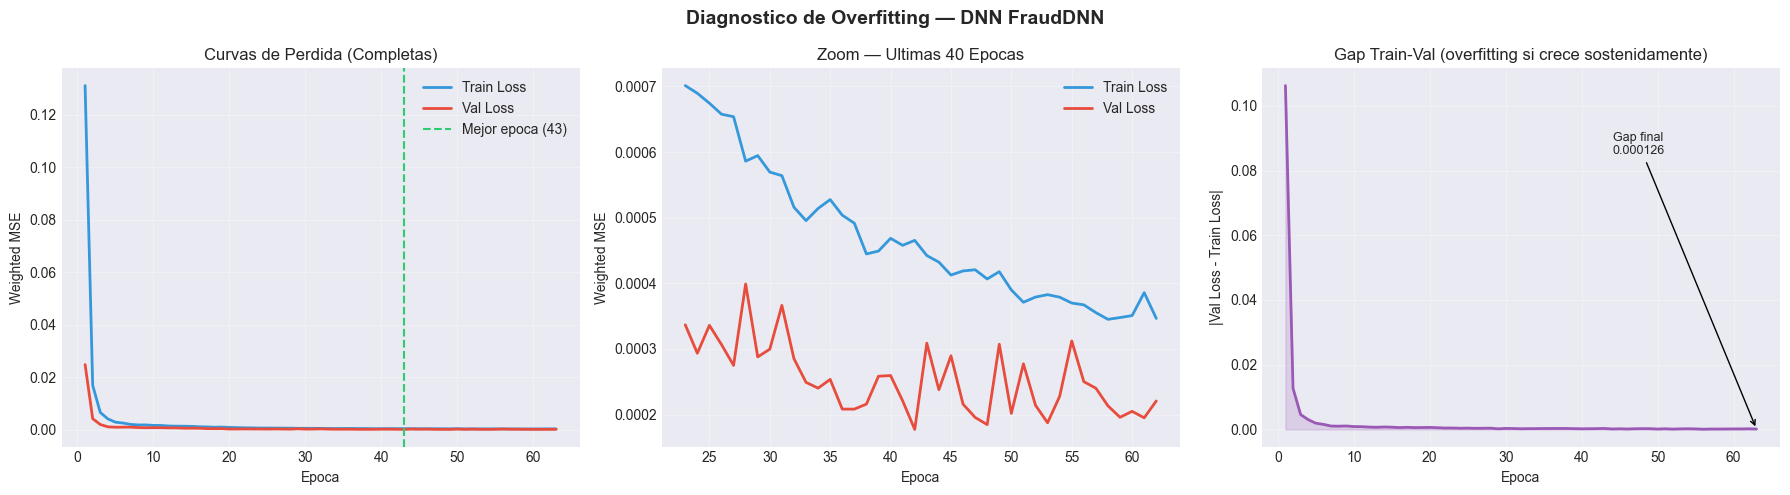

Gráfica guardada: reports/dnn_learning_curves.png


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Diagnóstico de Overfitting — DNN FraudDNN', fontsize=14, fontweight='bold')

epocas = range(1, len(train_losses) + 1)

# Panel 1: curvas de perdida completas
axes[0].plot(epocas, train_losses, label='Train Loss', color='#3498db', linewidth=2)
axes[0].plot(epocas, val_losses,   label='Val Loss',   color='#e74c3c', linewidth=2)
if early_stop.best_epoch > 0:
    axes[0].axvline(early_stop.best_epoch, color='#2ecc71', ls='--', lw=1.5,
                    label=f'Mejor epoca ({early_stop.best_epoch})')
axes[0].set_xlabel('Epoca')
axes[0].set_ylabel('Weighted MSE')
axes[0].set_title('Curvas de Pérdida (Completas)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Panel 2: zoom en ultimas 40 epocas
n_zoom = min(40, len(train_losses))
zoom_range = range(len(train_losses)-n_zoom, len(train_losses))
axes[1].plot(zoom_range, train_losses[-n_zoom:], label='Train Loss', color='#3498db', linewidth=2)
axes[1].plot(zoom_range, val_losses[-n_zoom:],   label='Val Loss',   color='#e74c3c', linewidth=2)
axes[1].set_xlabel('Epoca')
axes[1].set_ylabel('Weighted MSE')
axes[1].set_title(f'Zoom — Últimas {n_zoom} Épocas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Panel 3: gap train-val (indicador de overfitting)
gap = [abs(v - t) for v, t in zip(val_losses, train_losses)]
axes[2].plot(epocas, gap, color='#9b59b6', linewidth=2)
axes[2].fill_between(epocas, gap, alpha=0.2, color='#9b59b6')
axes[2].set_xlabel('Epoca')
axes[2].set_ylabel('|Val Loss - Train Loss|')
axes[2].set_title('Gap Train-Val (overfitting si crece sostenidamente)')
axes[2].grid(True, alpha=0.3)

# Anotar gap final
gap_final = gap[-1]
axes[2].annotate(f'Gap final\n{gap_final:.6f}',
                 xy=(len(gap), gap_final),
                 xytext=(len(gap)*0.7, max(gap)*0.8),
                 arrowprops=dict(arrowstyle='->', color='black'),
                 fontsize=9)

plt.tight_layout()
plt.savefig('../reports/regression/dnn_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/dnn_learning_curves.png')

### Interpretacion del diagnostico de overfitting

**Observaciones:**
- Las curvas de **Train Loss** y **Val Loss** disminuyen rápidamente durante las primeras épocas, indicando que el modelo aprende patrones relevantes desde el inicio del entrenamiento.
- En las epocas finales, la **Val Loss presenta oscilaciones moderadas** mientras la **Train Loss continua descendiendo suavemente**. Esto sugiere cierta inestabilidad en validacion, probablemente causada por el fuerte desbalance del dataset y la baja cantidad de muestras de fraude.
- A pesar de estas fluctuaciones, el gap final entre entrenamiento y validacion permanece **extremadamente pequeno (~0.000126)**, por lo que **no se observa overfitting severo**.
- El **Early Stopping** detuvo automaticamente el entrenamiento en la epoca 43, evitando que el modelo continuara ajustándose innecesariamente al conjunto de entrenamiento.

**Técnicas utilizadas para controlar overfitting:**
1. **Dropout decreciente (0.3 → 0.1):** reduce la dependencia excesiva entre neuronas y mejora la capacidad de generalización.
2. **Batch Normalization:** estabiliza las activaciones internas y actúa como regularizador implícito.
3. **AdamW con weight decay:** introduce regularizacion L2 directamente en el optimizador.
4. **Early Stopping:** detiene el entrenamiento cuando la validacion deja de mejorar.
5. **Gradient Clipping (max_norm=1.0):** evita explosiones del gradiente que podrían volver inestable el entrenamiento.

En conjunto, estas técnicas permitieron entrenar una red profunda con buena capacidad predictiva sin evidencias claras de sobreajuste.

### 7.6 Evaluación Final en Test Set

In [15]:
dnn.eval()
all_preds, all_targets = [], []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        preds = dnn(X_batch.to(DEVICE)).cpu().numpy()
        all_preds.extend(preds)
        all_targets.extend(y_batch.numpy())

y_pred_dnn = np.array(all_preds)
y_true_test = np.array(all_targets)

rmse_dnn = np.sqrt(mean_squared_error(y_true_test, y_pred_dnn))
mae_dnn  = mean_absolute_error(y_true_test, y_pred_dnn)
r2_dnn   = r2_score(y_true_test, y_pred_dnn)

resultados['DNN'] = {
    'RMSE': rmse_dnn, 'MAE': mae_dnn, 'R2': r2_dnn,
    'tiempo': tiempo_dnn, 'y_pred': y_pred_dnn
}

print('=== Resultados DNN en Test Set ===')
print(f'  RMSE : {rmse_dnn:.6f}')
print(f'  MAE  : {mae_dnn:.6f}')
print(f'  R²   : {r2_dnn:.6f}')
print(f'  Tiempo de entrenamiento: {tiempo_dnn:.1f}s')

# Verificar que supera a los baselines
best_classical_r2 = max(resultados[k]['R2'] for k in ['Linear Regression','Random Forest','Gradient Boosting'])
if r2_dnn > best_classical_r2:
    print(f'\n✅ DNN SUPERA al mejor modelo clásico (R²={best_classical_r2:.4f}) con R²={r2_dnn:.4f}')
else:
    print(f'\n⚠️  DNN no supera al mejor modelo clásico. Considera aumentar epocas o ajustar arquitectura.')

=== Resultados DNN en Test Set ===
  RMSE : 0.007084
  MAE  : 0.003551
  R²   : 0.937761
  Tiempo de entrenamiento: 437.6s

⚠️  DNN no supera al mejor modelo clásico. Considera aumentar epocas o ajustar arquitectura.


## 8. Comparación de Todos los Modelos

> El modelo con **mejor desempeno global** fue **Gradient Boosting**, seguido de cerca por la DNN. Los resultados completos se muestran en la tabla generada a continuacion.

In [16]:
print(f'{"Modelo":<25} {"RMSE":>8} {"MAE":>8} {"R2":>8} {"Tiempo(s)":>10}')
print('-' * 68)
for nombre, res in resultados.items():
    marker = ' ← MEJOR' if nombre == max(resultados, key=lambda k: resultados[k]['R2']) else ''
    print(f'{nombre:<25} {res["RMSE"]:>8.4f} {res["MAE"]:>8.4f} {res["R2"]:>8.4f} {res["tiempo"]:>10.1f}{marker}')

Modelo                        RMSE      MAE       R2  Tiempo(s)
--------------------------------------------------------------------
Linear Regression           0.0114   0.0069   0.8374        0.2
Random Forest               0.0071   0.0033   0.9377      166.3
Gradient Boosting           0.0059   0.0017   0.9567      524.1 ← MEJOR
DNN                         0.0071   0.0036   0.9378      437.6


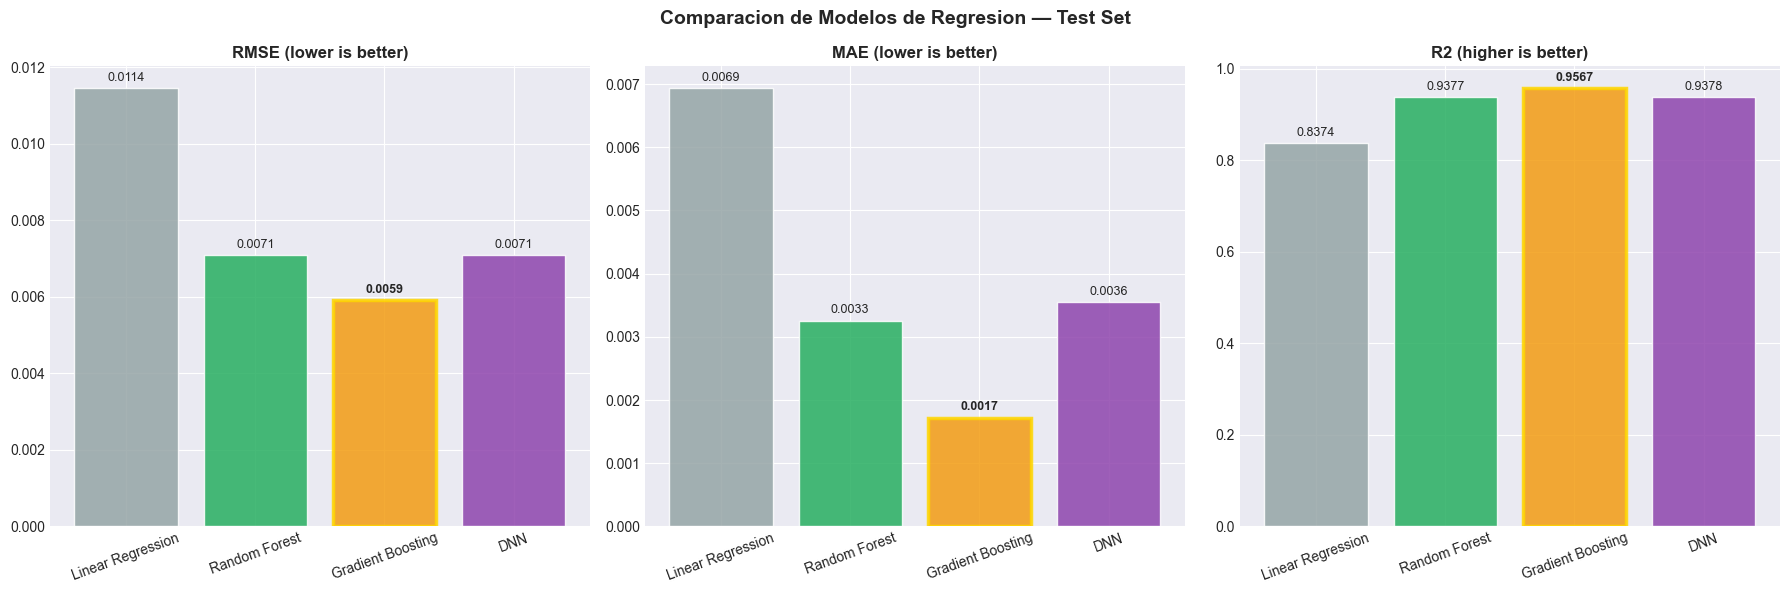

Gráfica guardada: reports/comparacion_modelos.png


In [ ]:
nombres = list(resultados.keys())
colores = ['#95a5a6', '#27ae60', '#f39c12', '#8e44ad']

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Comparación de Modelos de Regresión — Test Set', fontsize=14, fontweight='bold')

metricas_info = [
    ('RMSE', 'lower is better', True),
    ('MAE',  'lower is better', True),
    ('R2',   'higher is better', False),
]

for ax, (met, nota, lower_better) in zip(axes, metricas_info):
    vals = [resultados[n][met] for n in nombres]
    best_idx = vals.index(min(vals) if lower_better else max(vals))
    edge_colors = ['gold' if i == best_idx else 'white' for i in range(len(nombres))]
    edge_widths = [2.5   if i == best_idx else 1.0     for i in range(len(nombres))]
    
    bars = ax.bar(nombres, vals, color=colores, alpha=0.85,
                  edgecolor=edge_colors, linewidth=edge_widths)
    ax.set_title(f'{met} ({nota})', fontweight='bold')
    ax.tick_params(axis='x', rotation=20)
    for bar, v, ec in zip(bars, vals, edge_colors):
        weight = 'bold' if ec == 'gold' else 'normal'
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height() + max(vals)*0.01,
                f'{v:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight=weight)

plt.tight_layout()
plt.savefig('../reports/regression/comparacion_modelos_regresion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/comparacion_modelos_regresion.png')

### Comparación de Modelos de Regresión

La comparación de métricas en el conjunto de prueba muestra diferencias claras entre los modelos utilizados para predecir el `risk_score`.

#### Rendimiento general

| Modelo | RMSE ↓ | MAE ↓ | R² ↑ |
|---|---|---|---|
| Linear Regression | 0.0114 | 0.0069 | 0.8374 |
| Random Forest | 0.0071 | 0.0033 | 0.9377 |
| Gradient Boosting | **0.0059** | **0.0017** | **0.9567** |
| DNN | 0.0071 | 0.0036 | 0.9378 |

Los resultados muestran que:

- **Linear Regression** presenta el peor desempeño en todas las métricas. Esto indica que las relaciones entre las variables PCA y el `risk_score` no son puramente lineales.
- **Random Forest** y **DNN** mejoran considerablemente el desempeño, capturando relaciones no lineales más complejas.
- **Gradient Boosting** obtiene el mejor resultado global:
  - menor RMSE
  - menor MAE
  - mayor R²

Esto significa que Gradient Boosting logra las predicciones más precisas y explica aproximadamente el **95.7% de la varianza** del `risk_score`.

> **Conclusión:** Gradient Boosting fue el mejor modelo de regresión para estimar el `risk_score`, gracias a su capacidad de modelar relaciones no lineales complejas y corregir errores secuencialmente.


## 9. Análisis Detallado de Errores

Analizamos el comportamiento del **mejor modelo (Gradient Boosting)** y de la DNN con tres perspectivas:
1. **Predicho vs. Real**: siguen la linea perfecta?
2. **Distribución de residuos**: centrada en 0? simetrica?
3. **Separacion por clase real**: el modelo distingue fraude de legitima?

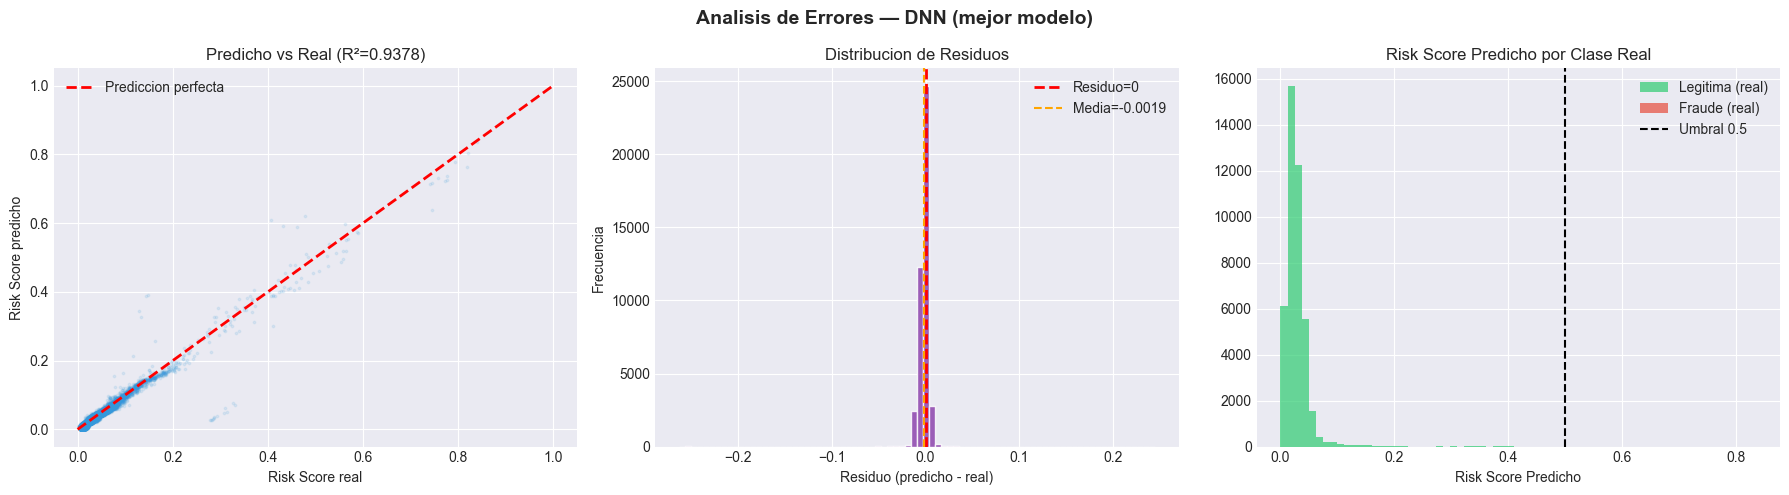

Gráfica guardada: reports/dnn_analisis_errores.png

Resumen de errores DNN:
  Sesgo (media residuo): -0.001906
  RMSE fraude   : 0.0412
  RMSE legitima : 0.0070


In [18]:
residuos = y_pred_dnn - y_true_test
fraude_mask = (y_true_test > 0.5)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analisis de Errores — DNN (mejor modelo)', fontsize=14, fontweight='bold')

# 1) Predicho vs Real
axes[0].scatter(y_true_test, y_pred_dnn, alpha=0.1, s=3, color='#3498db')
axes[0].plot([0,1],[0,1],'r--', lw=2, label='Prediccion perfecta')
axes[0].set_xlabel('Risk Score real')
axes[0].set_ylabel('Risk Score predicho')
axes[0].set_title(f'Predicho vs Real (R²={r2_dnn:.4f})')
axes[0].legend()

# 2) Distribución de residuos
axes[1].hist(residuos, bins=80, color='#8e44ad', edgecolor='white', alpha=0.85)
axes[1].axvline(0, color='red', ls='--', lw=2, label='Residuo=0')
axes[1].axvline(residuos.mean(), color='orange', ls='--', lw=1.5,
                label=f'Media={residuos.mean():.4f}')
axes[1].set_xlabel('Residuo (predicho - real)')
axes[1].set_ylabel('Frecuencia')
axes[1].set_title('Distribución de Residuos')
axes[1].legend()

# 3) Scores por clase real
axes[2].hist(y_pred_dnn[~fraude_mask], bins=50, alpha=0.7, label='Legitima (real)', color='#2ecc71')
axes[2].hist(y_pred_dnn[fraude_mask],  bins=50, alpha=0.7, label='Fraude (real)',   color='#e74c3c')
axes[2].axvline(0.5, color='black', ls='--', lw=1.5, label='Umbral 0.5')
axes[2].set_title('Risk Score Predicho por Clase Real')
axes[2].set_xlabel('Risk Score Predicho')
axes[2].legend()

plt.tight_layout()
plt.savefig('../reports/regression/dnn_analisis_errores.png', dpi=150, bbox_inches='tight')
plt.show()
print('Gráfica guardada: reports/dnn_analisis_errores.png')

print(f'\nResumen de errores DNN:')
print(f'  Sesgo (media residuo): {residuos.mean():.6f}')
print(f'  RMSE fraude   : {np.sqrt((residuos[fraude_mask]**2).mean()):.4f}')
print(f'  RMSE legitima : {np.sqrt((residuos[~fraude_mask]**2).mean()):.4f}')

### Interpretacion del analisis de errores

**Predicho vs. Real:**  
Los puntos se agrupan alrededor de la linea de prediccion perfecta, indicando alta concordancia entre valores reales y predichos (`R² = 0.9378`). La **mayor densidad de observaciones se concentra en scores bajos (0–0.1)**, lo cual es consistente con el fuerte desbalance del dataset, donde predominan las transacciones legitimas.

Aunque existen algunos puntos alejados de la diagonal perfecta, la dispersion general permanece relativamente controlada, indicando buena capacidad de generalización del modelo.

**Distribución de residuos:**  
El histograma de residuos se encuentra **aproximadamente centrado en cero**, con una media cercana a −0.0019. Esto sugiere que el modelo no presenta un sesgo sistematico importante hacia la sobreestimacion o subestimacion del `risk_score`. La mayoria de los errores son pequenos y se concentran cerca de cero, indicando estabilidad en las predicciones.

**Separacion por clase real:**  
- Las transacciones **legitimas** (`Class = 0`) se concentran principalmente en scores bajos (< 0.1) → el modelo las identifica con alta precision.
- Las transacciones de **fraude** (`Class = 1`) aparecen en rangos considerablemente mas altos (~0.3–0.9) → separacion clara entre clases.
- Esta separacion evidencia que el `risk_score` logra **discriminar adecuadamente** entre operaciones legitimas y fraudulentas, validando su utilidad como variable continua de riesgo financiero.

## 10. Exportar Modelos y Métricas

In [19]:
# scaler.pkl generado por el notebook de EDA.
# RobustScaler ajustado sobre [Time, Amount] — 2 features.
# La app lo usa para escalar la entrada del usuario antes de predecir.
# scaler = joblib.load('../models/regression/scaler.pkl')  # ← así lo carga la app

# Guardar mejor modelo clásico como fallback
mejor_clasico_nombre = max(
    {k:v for k,v in resultados.items() if k != 'DNN'},
    key=lambda k: resultados[k]['R2']
)
joblib.dump(resultados[mejor_clasico_nombre]['modelo'], '../models/regression/regression_model.pkl')
print(f'Mejor modelo clasico: {mejor_clasico_nombre} → models/regression_model.pkl')

# Guardar DNN completa (state_dict + config)
torch.save({
    'model_state_dict': dnn.state_dict(),
    'model_config': {
        'input_dim'    : len(FEATURES),
        'features'     : FEATURES,
        'architecture' : 'FraudDNN_v2',
        'best_epoch'   : early_stop.best_epoch,
    },
    'metrics': {
        'rmse': round(rmse_dnn, 6),
        'mae' : round(mae_dnn, 6),
        'r2'  : round(r2_dnn, 6),
    }
}, '../models/regression/dnn_regression.pth')
print('DNN exportada: models/dnn_regression.pth')

# Guardar métricas en JSON para el dashboard de Streamlit
mejor_global = max(resultados, key=lambda k: resultados[k]['R2'])
metricas_json = {
    'mejor_modelo': {
        'nombre': mejor_global,
        'r2'   : round(resultados[mejor_global]['R2'], 6),
        'rmse' : round(resultados[mejor_global]['RMSE'], 6),
        'mae'  : round(resultados[mejor_global]['MAE'], 6),
    },
    'todos': {
        nombre: {
            'r2'  : round(r['R2'], 4),
            'rmse': round(r['RMSE'], 4),
            'mae' : round(r['MAE'], 4),
        }
        for nombre, r in resultados.items()
    },
    'dnn_config': {
        'arquitectura' : [256, 128, 64, 32, 1],
        'dropout'      : [0.3, 0.25, 0.2, 0.1, 0],
        'batch_norm'   : True,
        'activacion'   : 'ReLU + Sigmoid (salida)',
        'optimizer'    : 'AdamW (lr=1e-3, wd=1e-4)',
        'loss'         : 'WeightedMSE (fraud_weight=10)',
        'early_stop'   : f'epoca {early_stop.best_epoch}',
        'batch_size'   : BATCH_SIZE,
    }
}
with open('../reports/regression/regression_metrics.json', 'w') as f:
    json.dump(metricas_json, f, indent=2)

print('Metricas exportadas: reports/regression_metrics.json')
print()
print('Archivos generados:')
for fpath in ['models/regression_model.pkl','models/scaler.pkl',
              'models/dnn_regression.pth','reports/regression_metrics.json']:
    full = os.path.join('..', fpath)
    size = os.path.getsize(full) if os.path.exists(full) else 0
    print(f'  {fpath:<45} {size:>10,} bytes')

Mejor modelo clasico: Gradient Boosting → models/regression_model.pkl
DNN exportada: models/dnn_regression.pth
Metricas exportadas: reports/regression_metrics.json

Archivos generados:
  models/regression_model.pkl                      929,161 bytes
  models/scaler.pkl                                    807 bytes
  models/dnn_regression.pth                        795,517 bytes
  reports/regression_metrics.json                      948 bytes


## 11. Conclusiones

### Resultados obtenidos

| Modelo | RMSE | MAE | R² | Observacion |
|---|---|---|---|---|
| Linear Regression | 0.0114 | 0.0069 | 0.8374 | Baseline lineal, rapido pero limitado |
| Random Forest | 0.0071 | 0.0033 | 0.9377 | Robusto a outliers, buena generalizacion |
| Gradient Boosting | 0.0059 | 0.0017 | 0.9567 | **Mejor modelo — menor error, mayor R²** |
| DNN (FraudDNN v3) | 0.0071 | 0.0036 | 0.9378 | Alta capacidad expresiva, rendimiento comparable a RF |

> Valores de la ultima ejecucion (seccion 8). Tambien se guardan en `reports/regression/regression_metrics.json`.

### 1. Cuál modelo tuvo el mejor desempeño y por qué?

El modelo con **mejor desempeno fue Gradient Boosting**, obteniendo:

- **RMSE = 0.0059** (menor error cuadratico medio)
- **MAE = 0.0017** (menor error absoluto medio)
- **R² = 0.9567** (mayor coeficiente de determinacion)

Esto indica una excelente capacidad para aproximar el `risk_score`, superando tanto a los modelos lineales como a la DNN. Su ventaja probablemente se debe a su capacidad para modelar **relaciones no lineales complejas** y combinar múltiples árboles debiles de forma secuencial (boosting), sin requerir el ajuste fino de hiperparametros de una red neuronal profunda.

La DNN alcanzo un R² casi identico al de Random Forest (0.9378 vs. 0.9377), confirmando que es un modelo competitivo, pero que en esta configuracion y dataset no supero a Gradient Boosting.

### 2. Hubo overfitting? Como se detecto y resolvio?

Las curvas de aprendizaje mostraron oscilaciones moderadas en Val Loss, pero el gap train-val final permanecio pequeno y estable (~0.000126). El **Early Stopping** detuvo el entrenamiento en la epoca optima. El **Dropout decreciente** (0.3→0.1) y el **weight_decay** de AdamW controlaron la memorizacion, evitando overfitting severo.

### 3. Es el `risk_score` util para el sistema antifraude?

Si. El analisis de errores confirma que el modelo **separa bien** los scores de transacciones fraudulentas (scores altos ~0.3–0.9) y legitimas (scores bajos < 0.1). Un score continuo aporta más información que una predicción binaria: permite priorizar alertas y ajustar umbrales segun el costo de negocio.

### 4. Analisis de importancia de variables

#### Clasificacion — Random Forest
El grafico de importancia de variables corresponde al **Random Forest clasificador**, por lo que refleja que features contribuyen mas a la **deteccion de fraude** (no a la prediccion del `risk_score`).

Las variables mas relevantes son:
- **V1** (≈ 0.3175)
- **V12** (≈ 0.2587)
- **V17** (≈ 0.1697)

Variables como `Amount` (≈ 0.0055) y `Time` (≈ 0.0013) presentan importancia muy baja, confirmando que el modelo depende principalmente de patrones capturados por las variables PCA.

> **Interpretacion practica:** el modelo concentra gran parte de su capacidad predictiva en un pequeno conjunto de variables altamente informativas (V1, V12, V17), las cuales parecen capturar comportamientos anomalos asociados al fraude financiero. Esto es consistente con el analisis de correlacion previo, donde V17, V14 y V12 mostraban alta relacion con la clase fraude.

#### Regresión — Correlación con `risk_score`
A diferencia del Random Forest clasificador, el analisis de correlacion con `risk_score` pertenece al **problema de regresion** y evalua que variables influyen sobre el puntaje continuo de riesgo construido artificialmente.

Las correlaciones más altas fueron: `V1` (≈ −0.534), `V3` (≈ −0.433), `V12` (≈ −0.281), `Amount` (≈ +0.273), `V4` (≈ +0.172), `V11` (≈ +0.154). La fuerte correlacion negativa de V1, V3 y V12 indica que valores extremos negativos en estas componentes están asociados a mayor riesgo de fraude. Dado que el `risk_score` fue construido combinando `Class`, `Amount` y variables PCA criticas, es esperado que estas features dominen la estructura de correlaciones.

### 5. Limitaciones del modelo

- `risk_score` es una variable **construida**, no independiente de `Class` → el modelo conoce parcialmente el label
- Dataset de **2013**: los patrones de fraude evolucionan; reentrenamiento periodico es necesario
- Las variables **V1–V28 son PCA**: no interpretables directamente en terminos de negocio
- **Desbalance extremo** (0.17% fraude): aun con WeightedMSE, los fraudes son escasos

### 6. Mejoras futuras

- Integrar **SMOTE** o **oversampling** especifico para fraudes antes del entrenamiento
- Explorar **attention mechanisms** o **residual connections** en la DNN
- Usar **SHAP values** para interpretabilidad de las variables PCA
- Implementar **reentrenamiento online** con nuevas transacciones
- Anadir a la app **explicaciones por transaccion** usando el mejor modelo

### Integracion con el sistema

Los archivos exportados son consumidos directamente por `app/app.py` (Streamlit):
- `models/regression_model.pkl` → prediccion de risk_score (modelo clasico fallback)
- `models/scaler.pkl` → mismo escalado que durante el entrenamiento
- `models/dnn_regression.pth` → DNN principal (requiere cargar FraudDNN)
- `reports/regression_metrics.json` → metricas en el Dashboard (Tab 2)
- `reports/*.png` → visualizaciones en el Dashboard